In [ ]:
import pandas as pd
import numpy as np
from tcn import TCN

2026-04-10 21:26:38.595202: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-10 21:26:38.625814: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-10 21:26:39.315983: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [82]:
df = pd.read_csv('data/WTP_raw_data.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7305 entries, 0 to 7304
Data columns (total 42 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Year                                          7305 non-null   int64  
 1   Month                                         7305 non-null   object 
 2   Day                                           7305 non-null   object 
 3   Date                                          7305 non-null   object 
 4   [Raw] Flow [m3/d]                             3947 non-null   float64
 5   [Raw] Alkalinity as CaCO3 [mg/L]              3819 non-null   float64
 6   [Raw] Max Turbidity [NTU]                     4018 non-null   float64
 7   [Raw] Min Turbidity [NTU]                     4018 non-null   float64
 8   [Raw] Mean Turbidity [NTU]                    4018 non-null   float64
 9   [Raw] E.Coli [cfu/100mL]                      1038 non-null   f

In [4]:
df.describe()

,Year,[Raw] Flow [m3/d],[Raw] Alkalinity as CaCO3 [mg/L],[Raw] Max Turbidity [NTU],[Raw] Min Turbidity [NTU],[Raw] Mean Turbidity [NTU],[Raw] E.Coli [cfu/100mL],[Raw] TC [cfu/100mL],[Raw] Temperature [°C],[Raw] DOC [mg/L],...,[TW] Al [mg/L],[TW] Turbidity [NTU],[TW] HAA [ug/L],[TW] THM [ug/L],[TW] TAN [mg/L],[TW] NO3-N [mg/L],[TW] NO2-N [mg/L],[TW] E. Coli [cfu/100mL],[TW] MIB [ug/L],[TW] Geosmin [ug/L]
count,7305.000000,3947.000000,3819.000000,4018.000000,4018.000000,4018.000000,1038.000000,1038.000000,7259.000000,338.000000,...,7293.000000,2.626000e+03,34.000000,82.000000,601.000000,627.000000,627.000000,1047.000000,229.000000,229.000000
mean,2015.500342,55568.951355,106.292223,15.673472,6.347949,9.853624,9.564547,103.235067,12.284119,1.956509,...,0.072437,7.062884e+03,5.767647,16.719146,0.311281,0.448118,0.040000,0.002865,3.091703,3.502183
std,5.766617,18699.188944,13.734412,23.096651,8.425706,12.523306,29.897755,269.081900,8.799912,0.386150,...,1.325002,1.172398e+05,1.862341,8.583324,0.132597,0.229536,0.050153,0.069079,0.610846,1.798207
min,2006.000000,6.000000,12.000000,0.090000,0.040000,0.060000,0.000000,0.000000,0.030000,0.900000,...,0.000000,0.000000e+00,3.800000,0.370000,0.010000,0.020000,0.000000,0.000000,3.000000,3.000000
25%,2011.000000,41157.000000,100.000000,4.600000,2.300000,3.300000,2.000000,16.000000,3.400000,2.000000,...,0.020000,3.000000e-02,5.300000,9.050000,0.250000,0.300000,0.000000,0.000000,3.000000,3.000000
50%,2016.000000,53958.000000,105.000000,7.700000,3.500000,5.100000,2.000000,44.000000,11.830000,2.000000,...,0.041000,4.000000e-02,5.300000,15.200000,0.310000,0.420000,0.000000,0.000000,3.000000,3.000000
75%,2020.000000,68429.500000,115.000000,17.400000,6.700000,10.680000,10.000000,90.000000,21.200000,2.000000,...,0.074000,7.000000e-02,5.300000,23.850000,0.370000,0.600000,0.100000,0.000000,3.000000,3.000000
max,2025.000000,173209.000000,170.000000,603.000000,197.000000,180.000000,670.000000,4000.000000,27.800000,3.000000,...,113.000000,3.682944e+06,14.300000,35.000000,1.410000,1.620000,0.200000,2.000000,10.000000,17.000000


In [ ]:
def DataProcessing(input_df: pd.DataFrame) -> pd.DataFrame:
# [1] Take original data
# [2] start March 1st 2015
# [3] make sure all features are numerical (e.g., cos(date)) 
# [4] take only features of interest (i.e., remove the TW data, old aluminum input)  
# [5] add masked + prev mesured features for each column/feature 
# [6] forward filling

    # [1] Take original data
    df_copy = input_df.copy()
    
    # [2] start March 1st 2015
    df_copy["Date"] = pd.to_datetime(df_copy["Date"])
    start_date = pd.to_datetime("2015-03-01")
    start_idx = df_copy[df_copy["Date"] >= start_date].index[0] #first index where date is greater than or equal to start date
    df_copy = df_copy.loc[start_idx:].copy()
    
    # [3] make sure all features are numerical (e.g., cos(date)) 
    days_in_year = np.where(df_copy["Date"].dt.is_leap_year, 366, 365)
    theta = 2 * np.pi * df_copy["Date"].dt.dayofyear / days_in_year
    df_copy.insert((df_copy.columns.get_loc("Date")+1), "Date_cos", np.cos(theta))
    df_copy.insert((df_copy.columns.get_loc("Date")+2), "Date_sin", np.sin(theta))

    # [4] take only features of interest (i.e., remove the TW data, old aluminum input)  
    df_copy.drop(columns = "[Chem] Alum Dose [mg/L]", inplace = True) #old aluminum input
    downstream_feaures = df_copy.columns.get_loc("[Filt] Total Runtime [h]")
    initial_features = df_copy.columns.get_loc("Date_cos")
    df_copy = df_copy.iloc[:, initial_features:downstream_feaures].copy()

    # [5] add masked + prev mesured features for each column/feature 
    original_cols = list(df_copy.columns)
    
    i = 0
    while i < len(original_cols):
        col = original_cols[i] #index of original column
        insert_pos = df_copy.columns.get_loc(col) + 1
        mask = df_copy[col].notna().astype(int) #1 if notna, 0 if na

        pos = pd.Series(np.arange(len(df_copy)), index=df_copy.index)
        last_pos = pos.where(df_copy[col].notna()).ffill()
        prev = (pos - last_pos).where(~df_copy[col].notna(), 0).fillna(0).astype(int)

        df_copy.insert(insert_pos, f"{col}_mask", mask)
        df_copy.insert(insert_pos + 1, f"{col}_previouslymeasured", prev)
        i += 1

    # [6] nan filling
  
    df_copy[original_cols] = df_copy[original_cols].ffill().bfill() #in case there are still any remaining NAs at the beginning of the dataset, we can backfill them with the first valid value

    return df_copy
    

In [84]:
df_processed = DataProcessing(df)

In [85]:
# Align back to the original dates since DataProcessing removed the 'Date' column
aligned_dates = pd.to_datetime(df.loc[df_processed.index, "Date"])

In [91]:
train_processed = df_processed[aligned_dates.dt.year < 2023].copy()
val_processed   = df_processed[aligned_dates.dt.year == 2023].copy()
test_processed  = df_processed[aligned_dates.dt.year >= 2024].copy()

Train-Val-Test Split: 2863 days (Mar 1, 2015 - 2022), 731 days (2023), 365 days (2024-)

In [92]:
len(train_processed), len(val_processed), len(test_processed)

(2863, 365, 731)

In [53]:
def SlidingWindowWithTarget(df: pd.DataFrame, window_size: int, shift_step: int, target_col: str)-> list[tuple[pd.DataFrame, float]]:

    data = []

    i = 0
    while i + window_size < df.shape[0]:
        window = df.iloc[i:i+window_size, :] #up to, not including the target day
        target_value = df.iloc[i+window_size][target_col]  
        
        data.append((window, target_value))
        
        i += shift_step

    return data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")

train_data_scaled = scaler.fit_transform(train_processed)# Fit only on the training set to prevent data leakage
val_data_scaled = scaler.transform(val_processed)
test_data_scaled = scaler.transform(test_processed)

In [137]:
#tune windows/shift sizes here
train_windows = SlidingWindowWithTarget(train_data_scaled, window_size=7, shift_step=1, target_col="[Filt] Mean Turbidity [NTU]")
val_windows = SlidingWindowWithTarget(val_data_scaled, window_size=7, shift_step=1, target_col="[Filt] Mean Turbidity [NTU]")
test_windows = SlidingWindowWithTarget(test_data_scaled, window_size=7, shift_step=1, target_col="[Filt] Mean Turbidity [NTU]")

Model Training

In [56]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, mean_squared_log_error,
                             mean_absolute_error, mean_squared_error, max_error, mean_absolute_percentage_error)
from sklearn.metrics import r2_score


In [57]:
def get_regression_metrics(model, X, y_true):
    """
    Get a dicionary with regression metrics:

    model: sklearn model with predict method
    X: feature matrix
    y_true: ground truth labels
    """
    # Get predictions from the model using the provided features X
    y_predicted = model.predict(X)

    # Calculate the regression metrics using sklearn.metrics functions
    mae = mean_absolute_error(y_true, y_predicted)
    mse = mean_squared_error(y_true, y_predicted)
    maximum_error = max_error(y_true, y_predicted)
    mape =  mean_absolute_percentage_error(y_true, y_predicted)

    # Store the calculated metrics in a dictionary
    metrics_dict = {
        'mae': mae,
        'mse': mse,
        'max_error': maximum_error,
        'mape': mape
    }

    return metrics_dict

In [58]:
import xgboost as xgb

In [59]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.01,
    subsample=1,
    colsample_bytree=1.0,
    reg_lambda=10,
    reg_alpha=1,
    gamma=0.0,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds = 50
)

In [60]:
#separate features and target values for training
train_features = [train_windows[i][0].values.flatten() for i in range(len(train_windows))]
train_values = [train_windows[i][1] for i in range(len(train_windows))]

val_features = [val_windows[i][0].values.flatten() for i in range(len(val_windows))]
val_values = [val_windows[i][1] for i in range(len(val_windows))]

test_features = [test_windows[i][0].values.flatten() for i in range(len(test_windows))]
test_values = [test_windows[i][1] for i in range(len(test_windows))]

In [61]:
# Train XGBoost model on all training data
xgb_model.fit(train_features, train_values, eval_set = [(val_features, val_values)], verbose=False)

xgb_train_results = get_regression_metrics(xgb_model, train_features, train_values)
xgb_val_results = get_regression_metrics(xgb_model, val_features, val_values)
xgb_test_results = get_regression_metrics(xgb_model, test_features, test_values)

In [62]:
print("train:",xgb_train_results)
print("val:", xgb_val_results)
print("test:",xgb_test_results)

train: {'mae': 0.2944622039794922, 'mse': 0.5762350559234619, 'max_error': 18.98363145318908, 'mape': 0.8142485618591309}
val: {'mae': 0.3059372305870056, 'mse': 0.7753565907478333, 'max_error': 17.084512135368662, 'mape': 0.7838559746742249}
test: {'mae': 0.19475112855434418, 'mse': 0.5217277407646179, 'max_error': 11.817854442943613, 'mape': 0.5875974297523499}


In [63]:
# Calculate R² scores for both training and test sets
train_r2 = r2_score(train_values, xgb_model.predict(train_features))
val_r2 = r2_score(val_values, xgb_model.predict(val_features))
test_r2 = r2_score(test_values, xgb_model.predict(test_features))

print(f"Training R² Score: {train_r2:.6f}")
print(f"Validation R² Score: {val_r2:.6f}")
print(f"Test R² Score: {test_r2:.6f}")

turb_col = "[Filt] Mean Turbidity [NTU]"
naive_pred_test = np.array([window[turb_col].iloc[-1] for window, target in test_windows])
naive_test_r2 = r2_score(test_values, naive_pred_test)
print("Naive TEST R2:", naive_test_r2) #compare true test value with naive prediction

Training R² Score: 0.414381
Validation R² Score: 0.298988
Test R² Score: 0.324662
Naive TEST R2: -0.25393096595591147


In [64]:
from pathlib import Path
import os
from sklearn.metrics import r2_score

# --- infer window and shift sizes from current train_windows ---
# (Usually we infer from the data, but if you want to use the global 'window_size' 
#  defined earlier in the notebook, you could do that too. 
#  Here we keep logic that inspects the actual data shape.)
window_size = len(train_windows[0][0]) if len(train_windows) > 0 else np.nan
if len(train_windows) > 1:
    shift_size = int(train_windows[1][0].index[0] - train_windows[0][0].index[0])
else:
    shift_size = np.nan

segment_label = f"W{window_size}, S{shift_size}"

def f4(x):
    return "" if pd.isna(x) else f"{x:.4f}"

def f2(x):
    return "" if pd.isna(x) else f"{x:.2f}"

# --- build one segment in the screenshot-like format ---
segment_df = pd.DataFrame(
    [
        {"Segment": segment_label, "MAE": "", "MSE": "", "Max Error": "", "MAPE": "", "R2": ""},
        {"Segment": "Train", "MAE": f4(xgb_train_results["mae"]), "MSE": f4(xgb_train_results["mse"]),
         "Max Error": f4(xgb_train_results["max_error"]), "MAPE": f4(xgb_train_results["mape"]), "R2": f2(train_r2)},
        {"Segment": "Val", "MAE": f4(xgb_val_results["mae"]), "MSE": f4(xgb_val_results["mse"]),
         "Max Error": f4(xgb_val_results["max_error"]), "MAPE": f4(xgb_val_results["mape"]), "R2": f2(val_r2)},
        {"Segment": "Test", "MAE": f4(xgb_test_results["mae"]), "MSE": f4(xgb_test_results["mse"]),
         "Max Error": f4(xgb_test_results["max_error"]), "MAPE": f4(xgb_test_results["mape"]), "R2": f2(test_r2)},
        {"Segment": "Naive", "MAE": "", "MSE": "", "Max Error": "", "MAPE": "", "R2": f2(naive_test_r2)},
        {"Segment": "", "MAE": "", "MSE": "", "Max Error": "", "MAPE": "", "R2": ""},  # spacer row
    ],
    columns=["Segment", "MAE", "MSE", "Max Error", "MAPE", "R2"],
)

# --- output file setup ---
# Ensure we use an absolute path relative to the current working directory or notebook location
base_dir = Path.cwd()
metrics_csv_path = base_dir / "data/model_metrics_log.csv"

# Make sure the directory exists
metrics_csv_path.parent.mkdir(parents=True, exist_ok=True)

# --- append (never overwrite) ---
file_exists = metrics_csv_path.exists()

# Debug: Print what we are about to do
print(f"Writing to: {metrics_csv_path}")
print(f"File exists: {file_exists}")
print(f"Data to append (shape: {segment_df.shape}):")
print(segment_df)

try:
    segment_df.to_csv(metrics_csv_path, mode="a", header=not file_exists, index=False)
    print(f"Successfully appended metrics segment to: {metrics_csv_path}")
except Exception as e:
    print(f"Error writing to CSV: {e}")

Writing to: /home/kevzhu14/Documents/WTP/data/model_metrics_log.csv
File exists: True
Data to append (shape: (6, 6)):
   Segment     MAE     MSE Max Error    MAPE     R2
0  W32, S1                                         
1    Train  0.2945  0.5762   18.9836  0.8142   0.41
2      Val  0.3059  0.7754   17.0845  0.7839   0.30
3     Test  0.1948  0.5217   11.8179  0.5876   0.32
4    Naive                                    -0.25
5                                                  
Successfully appended metrics segment to: /home/kevzhu14/Documents/WTP/data/model_metrics_log.csv


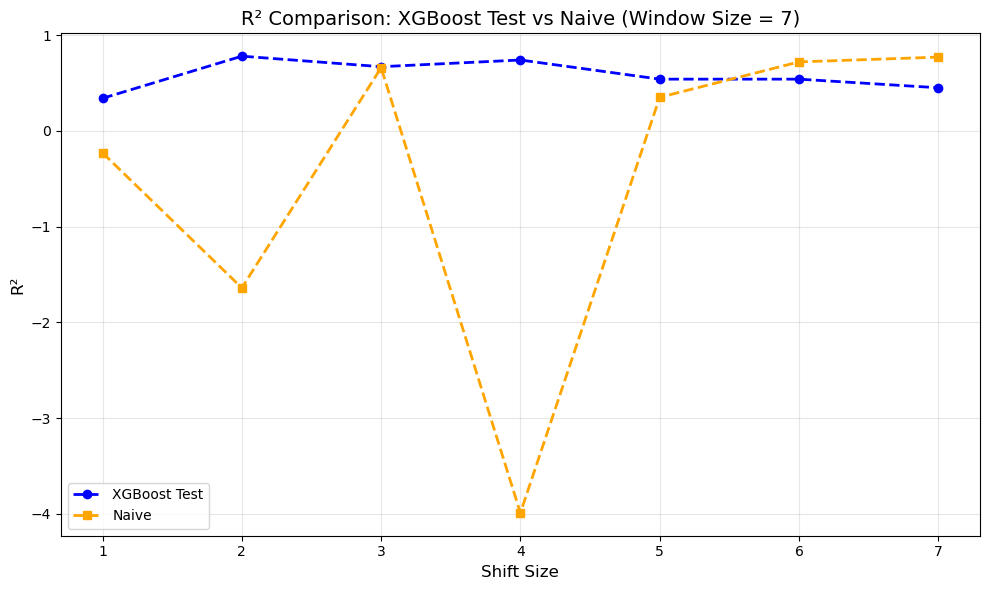

In [65]:
import matplotlib.pyplot as plt
import pandas as pd

# Read the metrics log
metrics_df = pd.read_csv('data/model_metrics_log.csv')

# defined lists to store results
shift_sizes = []
test_r2_values = []
naive_r2_values = []

# We are looking for Window Size 7
target_window_marker = "W7" 

i = 0
while i < len(metrics_df):
    segment = str(metrics_df.iloc[i]['Segment'])
    
    # 1. Find the Header Row (e.g., "W7, S3")
    if target_window_marker in segment and 'S' in segment:
        try:
            # Parse shift size from string like "W7, S3"
            current_shift = int(segment.split('S')[1])
            
            # Check if shift size is within range 1-7
            if 1 <= current_shift <= 7:
                # Look ahead for Test and Naive rows within the next few lines
                current_test_r2 = None
                current_naive_r2 = None
                
                # Scan the next 5 rows to find Test and Naive corresponding to this header
                for j in range(1, 6):
                    if i + j >= len(metrics_df): break
                    
                    row_segment = str(metrics_df.iloc[i+j]['Segment'])
                    row_r2 = metrics_df.iloc[i+j]['R2']
                    
                    if row_segment == 'Test':
                        current_test_r2 = float(row_r2)
                    elif row_segment == 'Naive':
                        current_naive_r2 = float(row_r2)
                
                # Only append if we found both metrics for this shift
                if current_test_r2 is not None and current_naive_r2 is not None:
                    shift_sizes.append(current_shift)
                    test_r2_values.append(current_test_r2)
                    naive_r2_values.append(current_naive_r2)
                
        except Exception as e:
            print(f"Error parsing row {i}: {e}")
            
    i += 1

# Create the plot
if len(shift_sizes) > 0:
    plt.figure(figsize=(10, 6))
    
    # Sort data by shift size for cleaner plotting
    sorted_indices = np.argsort(shift_sizes)
    
    # Filter for unique shift sizes to avoid duplicate points if multiple runs exist
    # (Optional but good practice if multiple runs for same config exist)
    
    plt.plot(np.array(shift_sizes)[sorted_indices], 
             np.array(test_r2_values)[sorted_indices], 
             'o--', label='XGBoost Test', color='blue', linewidth=2)
             
    plt.plot(np.array(shift_sizes)[sorted_indices], 
             np.array(naive_r2_values)[sorted_indices], 
             's--', label='Naive', color='orange', linewidth=2)

    plt.xlabel('Shift Size', fontsize=12)
    plt.ylabel('R²', fontsize=12)
    plt.title('R² Comparison: XGBoost Test vs Naive (Window Size = 7)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 8)) # Ensure x-axis shows 1-7
    plt.tight_layout()
    plt.show()
else:
    print("No matching data found for Window Size 7 (S1-S7). Check your CSV.")

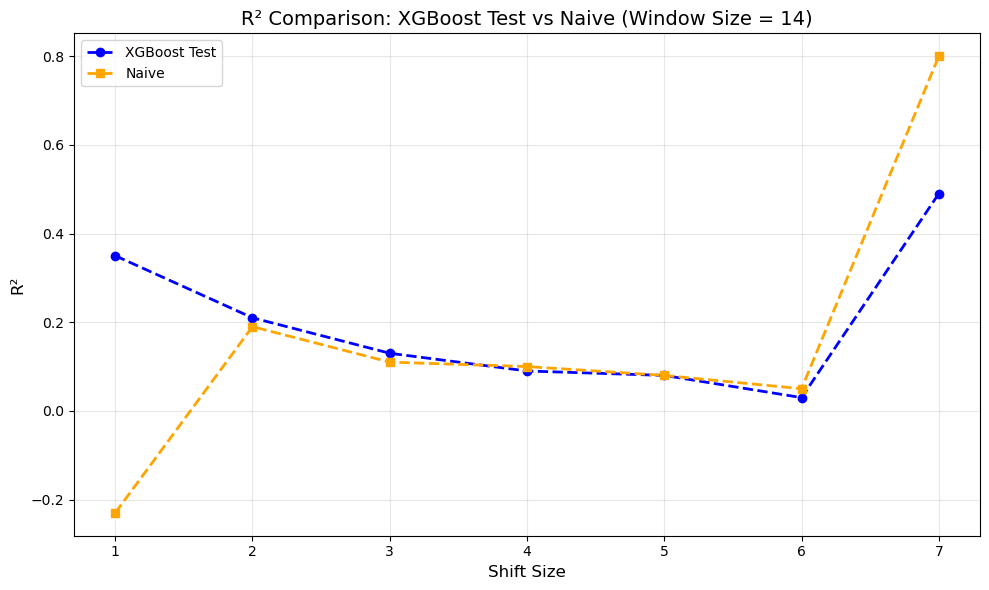

In [66]:
import pandas as pd

import matplotlib.pyplot as plt

# Read the metrics log
metrics_df = pd.read_csv('data/model_metrics_log.csv')

# defined lists to store results
shift_sizes = []
test_r2_values = []
naive_r2_values = []

# We are looking for Window Size 14
target_window_marker = "W14" 

i = 0
while i < len(metrics_df):
    segment = str(metrics_df.iloc[i]['Segment'])
    
    # 1. Find the Header Row (e.g., "W14, S3")
    if target_window_marker in segment and 'S' in segment:
        try:
            # Parse shift size from string like "W14, S3"
            current_shift = int(segment.split('S')[1])
            
            # Check if shift size is within range 1-7
            if 1 <= current_shift <= 7:
                # Look ahead for Test and Naive rows within the next few lines
                current_test_r2 = None
                current_naive_r2 = None
                
                # Scan the next 5 rows to find Test and Naive corresponding to this header
                for j in range(1, 6):
                    if i + j >= len(metrics_df): break
                    
                    row_segment = str(metrics_df.iloc[i+j]['Segment'])
                    row_r2 = metrics_df.iloc[i+j]['R2']
                    
                    if row_segment == 'Test':
                        current_test_r2 = float(row_r2)
                    elif row_segment == 'Naive':
                        current_naive_r2 = float(row_r2)
                
                # Only append if we found both metrics for this shift
                if current_test_r2 is not None and current_naive_r2 is not None:
                    shift_sizes.append(current_shift)
                    test_r2_values.append(current_test_r2)
                    naive_r2_values.append(current_naive_r2)
                
        except Exception as e:
            print(f"Error parsing row {i}: {e}")
            
    i += 1

# Create the plot
if len(shift_sizes) > 0:
    plt.figure(figsize=(10, 6))
    
    # Sort data by shift size for cleaner plotting
    sorted_indices = np.argsort(shift_sizes)
    
    plt.plot(np.array(shift_sizes)[sorted_indices], 
             np.array(test_r2_values)[sorted_indices], 
             'o--', label='XGBoost Test', color='blue', linewidth=2)
             
    plt.plot(np.array(shift_sizes)[sorted_indices], 
             np.array(naive_r2_values)[sorted_indices], 
             's--', label='Naive', color='orange', linewidth=2)

    plt.xlabel('Shift Size', fontsize=12)
    plt.ylabel('R²', fontsize=12)
    plt.title('R² Comparison: XGBoost Test vs Naive (Window Size = 14)', fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(range(1, 8)) # Ensure x-axis shows 1-7
    plt.tight_layout()
    plt.show()
else:
    print("No matching data found for Window Size 14 (S1-S7). Check your CSV.")

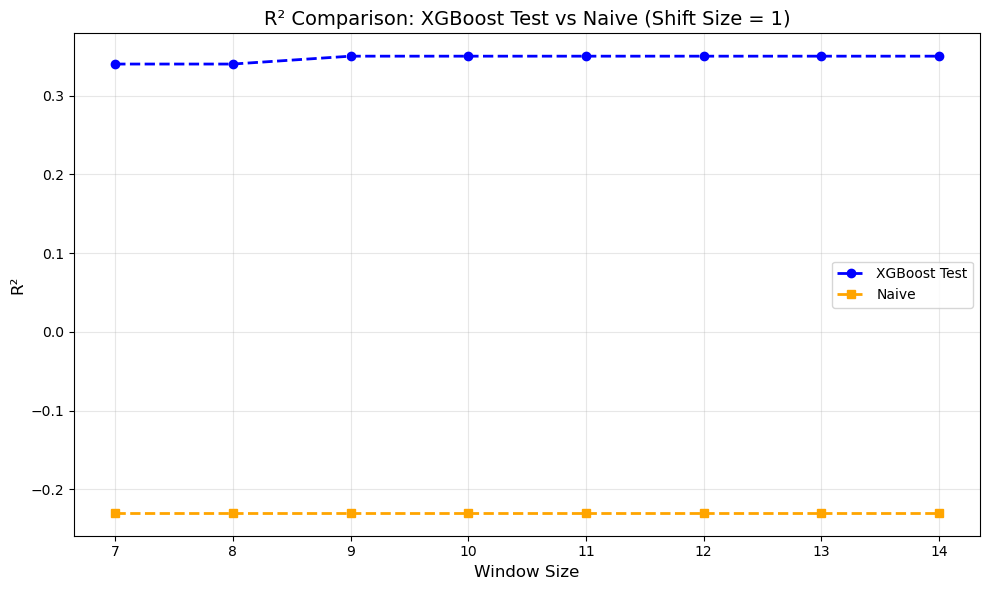

Data used for plotting:
   window_size  test_r2  naive_r2
0            7     0.34     -0.23
1            8     0.34     -0.23
2            9     0.35     -0.23
3           10     0.35     -0.23
4           11     0.35     -0.23
5           12     0.35     -0.23
6           13     0.35     -0.23
7           14     0.35     -0.23


In [67]:
# Plot R² vs window size (7-14) for shift size = 1, using all matching entries in the log
metrics_df = pd.read_csv("data/model_metrics_log.csv")

window_sizes = []
test_r2_values = []
naive_r2_values = []

i = 0
while i < len(metrics_df):
    segment = str(metrics_df.iloc[i]["Segment"])
    
    # Header row format: "W{window}, S{shift}"
    if segment.startswith("W") and ", S" in segment:
        try:
            w_part, s_part = segment.split(",")
            current_window = int(w_part.replace("W", "").strip())
            current_shift = int(s_part.replace("S", "").strip())

            if current_shift == 1 and 7 <= current_window <= 14:
                current_test_r2 = None
                current_naive_r2 = None

                # Look ahead for Test and Naive rows in the same block
                for j in range(1, 6):
                    if i + j >= len(metrics_df):
                        break

                    row_segment = str(metrics_df.iloc[i + j]["Segment"])
                    row_r2 = metrics_df.iloc[i + j]["R2"]

                    if row_segment == "Test" and pd.notna(row_r2):
                        current_test_r2 = float(row_r2)
                    elif row_segment == "Naive" and pd.notna(row_r2):
                        current_naive_r2 = float(row_r2)

                if current_test_r2 is not None and current_naive_r2 is not None:
                    window_sizes.append(current_window)
                    test_r2_values.append(current_test_r2)
                    naive_r2_values.append(current_naive_r2)

        except Exception as e:
            print(f"Skipping row {i} due to parse error: {e}")

    i += 1

if len(window_sizes) > 0:
    plot_df = pd.DataFrame({
        "window_size": window_sizes,
        "test_r2": test_r2_values,
        "naive_r2": naive_r2_values
    })

    # Use all matching data: aggregate repeated runs by mean per window size
    agg_df = (
        plot_df.groupby("window_size", as_index=False)[["test_r2", "naive_r2"]]
        .mean()
        .sort_values("window_size")
    )

    plt.figure(figsize=(10, 6))
    plt.plot(agg_df["window_size"], agg_df["test_r2"], "o--", label="XGBoost Test", color="blue", linewidth=2)
    plt.plot(agg_df["window_size"], agg_df["naive_r2"], "s--", label="Naive", color="orange", linewidth=2)

    plt.xlabel("Window Size", fontsize=12)
    plt.ylabel("R²", fontsize=12)
    plt.title("R² Comparison: XGBoost Test vs Naive (Shift Size = 1)", fontsize=14)
    plt.xticks(range(7, 15))
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    print("Data used for plotting:")
    print(agg_df)
else:
    print("No matching data found for shift size 1 and window sizes 7-14.")

Wavenet Model

In [34]:
from wavenet_model_edited import WaveNetModel

In [35]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [126]:
train_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2863 entries, 3346 to 6208
Data columns (total 69 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   Date_cos                                                         2863 non-null   float64
 1   Date_cos_mask                                                    2863 non-null   int64  
 2   Date_cos_previouslymeasured                                      2863 non-null   int64  
 3   Date_sin                                                         2863 non-null   float64
 4   Date_sin_mask                                                    2863 non-null   int64  
 5   Date_sin_previouslymeasured                                      2863 non-null   int64  
 6   [Raw] Flow [m3/d]                                                2863 non-null   float64
 7   [Raw] Flow [m3/d]_mask                      

In [141]:
# 1. PREPARE THE DATA 
# (Assuming train_windows, val_windows, test_windows are already created with window_size=7)

# Extract 3D arrays: Shape (Num_Samples, Window_Size, Num_Features)

train_X = [train_windows[i][0].values.flatten() for i in range(len(train_windows))]
train_y = [train_windows[i][1] for i in range(len(train_windows))]

val_X = [val_windows[i][0].values.flatten() for i in range(len(val_windows))]
val_y = [val_windows[i][1] for i in range(len(val_windows))]

test_X = [test_windows[i][0].values.flatten() for i in range(len(test_windows))]
test_y = [test_windows[i][1] for i in range(len(test_windows))]


# Extract targets (The day immediately following the 7-day window)
train_y = np.array([window[1] for window in train_windows])
val_y = np.array([window[1] for window in val_windows])
test_y = np.array([window[1] for window in test_windows])

# Convert to PyTorch Tensors and Transpose for Conv1d
# Shape goes from (Samples, 7, Features) -> (Samples, Features, 7)
# Rebuild X as 3D arrays (samples, window_size, features) for Conv1d
train_X = np.stack([window[0].values for window in train_windows]).astype(np.float32)
val_X = np.stack([window[0].values for window in val_windows]).astype(np.float32)
test_X = np.stack([window[0].values for window in test_windows]).astype(np.float32)

train_tensor_X = torch.tensor(train_X, dtype=torch.float32).transpose(1, 2)
train_tensor_y = torch.tensor(train_y, dtype=torch.float32)

val_tensor_X = torch.tensor(val_X, dtype=torch.float32).transpose(1, 2)
val_tensor_y = torch.tensor(val_y, dtype=torch.float32)

test_tensor_X = torch.tensor(test_X, dtype=torch.float32).transpose(1, 2)
test_tensor_y = torch.tensor(test_y, dtype=torch.float32)

# Create DataLoaders to feed data in batches
batch_size = 64
train_loader = DataLoader(TensorDataset(train_tensor_X, train_tensor_y), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(val_tensor_X, val_tensor_y), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(test_tensor_X, test_tensor_y), batch_size=batch_size, shuffle=False)

# ==========================================
# 2. INITIALIZE THE MODEL
# ==========================================

num_features = train_tensor_X.shape[1] 

#MODEL
model = WaveNetModel(num_features=train_processed.shape[1],
                      layers=3, 
                      blocks=1, 
                      dilation_channels=32, 
                      residual_channels=32, 
                      skip_channels=16, 
                      end_channels=16, 
                      kernel_size=2)

# Regression task means Mean Squared Error loss
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 3. THE TRAINING LOOP
# ==========================================

patience = 30  # How many epochs to wait for improvement before giving up
trigger_times = 0
best_val_loss = float('inf')
epochs = 1000 # Set a high limit

for epoch in range(epochs):
    # --- Training Phase ---
    model.train() # Set model to training mode
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()               # 1. Clear old gradients
        predictions = model(batch_X)        # 2. Forward pass
        loss = criterion(predictions, batch_y) # 3. Calculate error
        loss.backward()                     # 4. Backpropagate error
        optimizer.step()                    # 5. Update weights
        
        train_loss += loss.item() * batch_X.size(0)
    
    train_loss /= len(train_loader.dataset)
    
    # --- Validation Phase ---
    model.eval() # Set model to evaluation mode (disables dropout, etc.)
    val_loss = 0.0
    with torch.no_grad(): # Don't track gradients during validation to save memory
        for batch_X, batch_y in val_loader:
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            val_loss += loss.item() * batch_X.size(0)
            
    val_loss /= len(val_loader.dataset)


    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_wavenet.pth")
        trigger_times = 0
    
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping at epoch {epoch+1} with best val loss: {best_val_loss:.4f}")
            break

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:02d}/{epochs} | Train MSE: {train_loss:.4f} | Val MSE: {val_loss:.4f}")

# ==========================================
# 4. EVALUATION ON TEST SET (R^2 Score)
# ==========================================

print("\nEvaluating on Test Set...")

model.load_state_dict(torch.load("best_wavenet.pth"))
model.eval()
test_predictions = []
actuals = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        preds = model(batch_X)
        test_predictions.extend(preds.numpy())
        actuals.extend(batch_y.numpy())

# Calculate R^2 to compare against the XGBoost and Naive models
test_r2 = r2_score(actuals, test_predictions)
print(f"TCN Test R² Score: {test_r2:.4f}")

Epoch 01/1000 | Train MSE: 0.9732 | Val MSE: 0.6458
Epoch 10/1000 | Train MSE: 0.5545 | Val MSE: 1.0224
Epoch 20/1000 | Train MSE: 0.3109 | Val MSE: 1.3569
Epoch 30/1000 | Train MSE: 0.1803 | Val MSE: 1.1215
Epoch 40/1000 | Train MSE: 0.0829 | Val MSE: 0.5404
Epoch 50/1000 | Train MSE: 0.0710 | Val MSE: 0.5862
Epoch 60/1000 | Train MSE: 0.0608 | Val MSE: 0.6205
Early stopping at epoch 69 with best val loss: 0.5333

Evaluating on Test Set...
TCN Test R² Score: 0.0362


In [142]:
# Create dummy dataframes to inverse transform just the target column
dummy_pred = pd.DataFrame(np.zeros((len(test_predictions), train_processed.shape[1])), columns=train_processed.columns)
dummy_actual = dummy_pred.copy()

# Insert the scaled predictions/actuals into the target column
turb_idx = train_processed.columns.get_loc("[Filt] Mean Turbidity [NTU]")
dummy_pred.iloc[:, turb_idx] = test_predictions
dummy_actual.iloc[:, turb_idx] = actuals

# Inverse transform back to real NTU values
real_predictions = scaler.inverse_transform(dummy_pred)[:, turb_idx]
real_actuals = scaler.inverse_transform(dummy_actual)[:, turb_idx]

# Calculate True R2
true_test_r2 = r2_score(real_actuals, real_predictions)
print(f"True TCN Test R² Score (Unscaled): {true_test_r2:.4f}")

True TCN Test R² Score (Unscaled): 0.0362
